## Task7 
# Sensitive analysis添加traders样本
# 第1步：数据准备和验证

In [2]:
# 导入必要库
from src import *
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter


In [3]:
# 数据路径设置
drive_path = r'/Users/maoqingwang/Library/CloudStorage/GoogleDrive-mw3827@columbia.edu/Shared drives/' 
base_path = 'ColumbiaProject2025/RunsWithTimeStamps'
run_dir = os.path.join(drive_path, base_path)
directory = '20250827_1128_Nasdaq_1530'



In [4]:
DF = read_parquet_dir(os.path.join(run_dir, directory), daily = True, price = True, begin = pd.Timestamp('15:30'), end = pd.Timestamp('16:00'))

In [5]:
print("Columns in df:", DF.columns.tolist()[:20])  # First 20 columns
print("Has price column:", 'price' in DF.columns)
print("DataFrame shape:", DF.shape)
DF.head(100000)

Columns in df: ['0_long', '1_long', '2_short', '3_short', '4_long', '5_long', '6_long', '7_long', '8_long', '9_short', '10_short', '11_short', '12_long', '13_long', '14_long', '15_short', '16_long', '17_long', '18_long', '19_short']
Has price column: True
DataFrame shape: (10190, 268)


,0_long,1_long,2_short,3_short,4_long,5_long,6_long,7_long,8_long,9_short,...,258_long,259_long,260_long,261_long,262_short,263_short,264_short,265_short,naive_ave_pnl,price
timestamp,,,,,,,,,,,,,,,,,,,,,
2006-01-02 15:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1654.50
2006-01-02 16:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1654.50
2006-01-03 15:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1697.00
2006-01-03 16:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1693.00
2006-01-04 15:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1707.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-09 16:00:00,5058.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1887.0,8677.0,...,518.0,1988.0,3258.0,490.0,6349.0,4267.0,4169.0,8467.0,3270.413534,23053.00
2025-07-10 15:30:00,5058.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1887.0,8677.0,...,518.0,1988.0,3258.0,490.0,6349.0,4267.0,4169.0,8467.0,3270.413534,23028.25
2025-07-10 16:00:00,4993.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1822.0,8677.0,...,518.0,1988.0,3193.0,425.0,6349.0,4267.0,4169.0,8467.0,3265.281955,23012.00


In [6]:
DF = DF.apply(pd.to_numeric)

In [7]:
market = DF.iloc[1::2].reset_index(drop=True) - DF.iloc[::2].reset_index(drop=True)
market.index = DF.index[1::2].date
price = market['price'].cumsum()
df = DF.iloc[1::2]
df = df.drop(columns=['price'])
df.index = df.index.date
df['price'] = price
df

,0_long,1_long,2_short,3_short,4_long,5_long,6_long,7_long,8_long,9_short,...,258_long,259_long,260_long,261_long,262_short,263_short,264_short,265_short,naive_ave_pnl,price
2006-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00
2006-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-4.00
2006-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.00
2006-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00
2006-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,5058.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1207.0,1799.0,8677.0,...,518.0,1970.0,3170.0,420.0,6349.0,4267.0,4169.0,8467.0,3266.097744,-495.50
2025-07-08,5058.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1207.0,1817.0,8677.0,...,518.0,1988.0,3188.0,420.0,6349.0,4267.0,4169.0,8467.0,3267.518797,-491.00
2025-07-09,5058.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1887.0,8677.0,...,518.0,1988.0,3258.0,490.0,6349.0,4267.0,4169.0,8467.0,3270.413534,-473.50
2025-07-10,4993.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1822.0,8677.0,...,518.0,1988.0,3193.0,425.0,6349.0,4267.0,4169.0,8467.0,3265.281955,-489.75


In [8]:
long_columns = [c for c in df.columns if 'long' in c] + ['naive_ave_pnl', 'price']
short_columns = [c for c in df.columns if 'short' in c] + ['naive_ave_pnl', 'price']
long = df[long_columns]
short = df[short_columns]
print(long)
print(short)

            0_long  1_long  4_long  5_long  6_long  7_long  8_long  12_long  \
2006-01-02     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-03     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-04     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-05     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-06     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
...            ...     ...     ...     ...     ...     ...     ...      ...   
2025-07-07  5058.0  3353.0  2350.0  3443.0  1146.0  1207.0  1799.0    498.0   
2025-07-08  5058.0  3353.0  2350.0  3443.0  1146.0  1207.0  1817.0    498.0   
2025-07-09  5058.0  3353.0  2350.0  3443.0  1146.0  1277.0  1887.0    568.0   
2025-07-10  4993.0  3353.0  2350.0  3443.0  1146.0  1277.0  1822.0    568.0   
2025-07-11  4993.0  3353.0  2350.0  3443.0  1146.0  1277.0  1822.0    568.0   

            13_long  14_long  ...  254_long  255_lo

In [82]:
pnl_timeseries = {}

pnl_timeseries['long_pnl'] = long.filter(regex="_long$")
pnl_timeseries['short_pnl'] = short.filter(regex="_short$")
market_long = long['price']
market_short = short['price']

### 验证数据准备
确认以下要点：
1. ✅ metrics 计算没问题（使用已有的calc_metrics函数）
2. ✅ 已 split 成 long / short 两组
3. ✅ pnl_t 已改成 cumpnl
4. ✅ 所有 metric 都有正向化（高值=好，比如对 MDD 取负号）

## 第1.5步：检查Long/Short分离情况

在定义权重分类之前，先确认数据是否已经分为long和short两组

## 第2步：分别为Long和Short定义指标分类和权重

基于Long/Short分离的数据，我们将：
1. 定义四大类指标分类（对Long和Short通用）
2. 设置类别权重
3. 分别构建Long和Short的指标矩阵
4. 分别计算加权EI分数

### 四个大类定义（Long和Short通用）

In [83]:
# 更新四大类指标分类（按照最新要求）
metric_categories = {
    'Returns': {
        'description': '收益类指标 - 衡量策略的盈利能力',
        'metrics': [
            'drawup_beta',
            'pnl_t',
            'excess_mean_ret',
            'excess_ret',
            
        ]
    },

    'Drawdowns': {
        'description': '回撤类指标与风险衡量',
        'metrics': [
            'mdd_p',
            'ldd_p',
            'cvar_5',
            'drawdown_beta',
            'cdd_percent',
            'mdd_days',
            'ldd_days',
            'calmar_ratio'
        ]
    },

    'Length': {
        'description': '时长类指标 - 交易/回撤持续性',
        'metrics': [
            'days_since_first_trade',
            'success_rate'
        ]
    },

    'Volatility': {
        'description': '波动/风险度量',
        'metrics': [
            'sharpe'
        ]
    }
}

# 打印分类信息简要校验
for category, info in metric_categories.items():
    print(f"{category} 类:")
    print(f"  描述: {info['description']}")
    print(f"  指标数量: {len(info['metrics'])}")
    print(f"  指标: {', '.join(info['metrics'])}\n")

Returns 类:
  描述: 收益类指标 - 衡量策略的盈利能力
  指标数量: 4
  指标: drawup_beta, pnl_t, excess_mean_ret, excess_ret

Drawdowns 类:
  描述: 回撤类指标与风险衡量
  指标数量: 8
  指标: mdd_p, ldd_p, cvar_5, drawdown_beta, cdd_percent, mdd_days, ldd_days, calmar_ratio

Length 类:
  描述: 时长类指标 - 交易/回撤持续性
  指标数量: 2
  指标: days_since_first_trade, success_rate

Volatility 类:
  描述: 波动/风险度量
  指标数量: 1
  指标: sharpe



In [84]:
# 重新设置并管理多种权重配置（插入到CELL INDEX:13）
# 注意：本cell依赖于已存在的 `metric_categories` 变量

# 定义可用的权重方案（按四类：Returns, Drawdowns, Length, Volatility）
weight_schemes_raw = {
    'categories_average': {'rt': 0.25, 'drawdown': 0.25, 'len': 0.25, 'volatility': 0.25},
    'return_emphasize':    {'rt': 0.70, 'drawdown': 0.10, 'len': 0.10, 'volatility': 0.10},
    'drawdown_emphasize':  {'rt': 0.10, 'drawdown': 0.70, 'len': 0.10, 'volatility': 0.10},
    'length_emphasize':    {'rt': 0.10, 'drawdown': 0.10, 'len': 0.70, 'volatility': 0.10},
    'volatility_emphasize':{'rt': 0.10, 'drawdown': 0.10, 'len': 0.10, 'volatility': 0.70}
}

# 映射短键到 metric_categories 中实际的类别名（兼容不同命名）
_category_map = {}
for k in metric_categories.keys():
    kl = k.lower()
    if 'return' in kl:
        _category_map['rt'] = k
        _category_map['return'] = k
        _category_map['returns'] = k
    elif 'draw' in kl:
        _category_map['drawdown'] = k
        _category_map['drawdowns'] = k
    elif 'length' in kl or 'len' in kl:
        _category_map['len'] = k
        _category_map['length'] = k
    elif 'volat' in kl or 'volatility' in kl:
        _category_map['volatility'] = k

# 构建每个方案对应的分类权重与每个metric的细分权重
weight_schemes = {}
for scheme_name, raw in weight_schemes_raw.items():
    # 生成 category_weights 使用 metric_categories 的真实键
    cat_weights = {}
    for short_key, w in raw.items():
        cat_key = _category_map.get(short_key)
        if cat_key is None:
            raise KeyError(f"无法映射类别短键: {short_key} -> 请检查 metric_categories")
        cat_weights[cat_key] = float(w)
    # 验证归一化
    total = sum(cat_weights.values())
    if abs(total - 1.0) > 1e-8:
        # 归一化以防输入不是严格1.0
        cat_weights = {k: v/total for k, v in cat_weights.items()}
    # 计算每个metric的权重（在类别内平均分配）
    metric_weights = {}
    metric_to_category_local = {}
    for cat, info in metric_categories.items():
        metrics = info.get('metrics', [])
        n = len(metrics)
        if n == 0:
            continue
        per_metric = cat_weights[cat] / n
        for m in metrics:
            metric_weights[m] = per_metric
            metric_to_category_local[m] = cat
    weight_schemes[scheme_name] = {
        'category_weights': cat_weights,
        'metric_weights': metric_weights,
        'metric_to_category': metric_to_category_local
    }

# 提供应用某个权重方案的函数（会覆盖全局 detailed_metric_weights 等）
def apply_weight_scheme(scheme_name):
    """
    将指定的权重方案设为当前活跃配置（覆盖 detailed_metric_weights 等全局变量）。
    Args:
        scheme_name (str): 可用方案名，使用 `list_weight_schemes()` 查看
    """
    global initial_category_weights, detailed_metric_weights
    global metric_to_category, weighted_metrics_config, all_metrics, weight_vector

    if scheme_name not in weight_schemes:
        raise KeyError(f"未知的权重方案: {scheme_name}")

    scheme = weight_schemes[scheme_name]

    # 更新全局变量（兼容现有代码）
    # initial_category_weights 采用与之前相同的短键形式不是必须，但为兼容保留四类键名
    # 这里我们使用 metric_categories 的真实键名来保存类别权重
    initial_category_weights = scheme['category_weights']
    detailed_metric_weights = scheme['metric_weights']
    metric_to_category = scheme['metric_to_category']

    # 更新 weighted_metrics_config
    weighted_metrics_config = {
        'categories': metric_categories,
        'category_weights': initial_category_weights,
        'metric_weights': detailed_metric_weights,
        'metric_to_category': metric_to_category,
        'scheme': scheme_name
    }

    # 更新权重向量（alphabetical order）
    all_metrics = sorted(detailed_metric_weights.keys())
    weight_vector = [detailed_metric_weights[m] for m in all_metrics]

    print(f"已应用权重方案: {scheme_name}")
    print("类别权重:")
    for k, v in initial_category_weights.items():
        print(f"  {k}: {v:.3f}")
    print(f"指标总数: {len(all_metrics)}, 权重总和: {sum(weight_vector):.6f}")

def list_weight_schemes():
    """返回可用方案名列表"""
    return list(weight_schemes.keys())

# 默认应用 average 方案
apply_weight_scheme('categories_average')

# 输出可用方案供参考（用户可调用 apply_weight_scheme(...) 切换）
print("\n可用权重方案:")
for name in list_weight_schemes():
    print(" -", name)

# 示例：如果想立即应用某个方案，取消注释下面一行并运行
apply_weight_scheme('return_emphasize')

已应用权重方案: categories_average
类别权重:
  Returns: 0.250
  Drawdowns: 0.250
  Length: 0.250
  Volatility: 0.250
指标总数: 15, 权重总和: 1.000000

可用权重方案:
 - categories_average
 - return_emphasize
 - drawdown_emphasize
 - length_emphasize
 - volatility_emphasize
已应用权重方案: return_emphasize
类别权重:
  Returns: 0.700
  Drawdowns: 0.100
  Length: 0.100
  Volatility: 0.100
指标总数: 15, 权重总和: 1.000000


## 第6步：分别构建Long和Short的指标矩阵

基于加权指标分类系统，分别对Long策略和Short策略进行处理

In [85]:
long_metrics = calc_metrics(long)

/Users/maoqingwang/sauma-group/src/metrics.py:64: RuntimeWarning: invalid value encountered in divide
  sharpe = np.where(rstd == 0, 0, rmean / rstd * np.sqrt(252))
/Users/maoqingwang/sauma-group/src/metrics.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if dd[i] == 0:
/Users/maoqingwang/sauma-group/src/metrics.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  while j >= 0 and dd[j] > 0:
/Users/maoqingwang/sauma-group/src/metrics.py:64: RuntimeWarning: invalid value encountered in divide
  sharpe = np.where(rstd == 0, 0, rmean / rstd * np.sqrt(252))
/Users/maoqingwang/sauma-group/src/metrics.py:44: FutureWar

In [111]:
long1M = {}
for col, frame in long_metrics.items():
    frame.fillna(0, inplace=True)
    frame.index = pd.to_datetime(frame.index)
    long1M[col] = frame.resample('1M').last()

/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2326644324.py:5: FutureWarning: 'M'

In [88]:
short_metrics = calc_metrics(short)

/Users/maoqingwang/sauma-group/src/metrics.py:64: RuntimeWarning: invalid value encountered in divide
  sharpe = np.where(rstd == 0, 0, rmean / rstd * np.sqrt(252))
/Users/maoqingwang/sauma-group/src/metrics.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if dd[i] == 0:
/Users/maoqingwang/sauma-group/src/metrics.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  while j >= 0 and dd[j] > 0:
/Users/maoqingwang/sauma-group/src/metrics.py:64: RuntimeWarning: invalid value encountered in divide
  sharpe = np.where(rstd == 0, 0, rmean / rstd * np.sqrt(252))
/Users/maoqingwang/sauma-group/src/metrics.py:44: FutureWar

In [151]:
short1M = {}
for col, frame in short_metrics.items():
    frame.fillna(0, inplace=True)
    frame.index = pd.to_datetime(frame.index)
    short1M[col] = frame.resample('1M').last()

/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning:

/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/2996069348.py:5: FutureWarning:

In [103]:
def compute_EI_trader(dic: dict, alpha: float, weights = None) -> pd.DataFrame:
    positive_metrics_name = ['sharpe','pnl_t','days_since_first_trade',
        'drawup_beta','excess_mean_ret','excess_ret','success_rate']
    
    # re_arrange_df
    time_dic = {}
    # time_index = dic[pd.Timestamp('2006-01-31 00:00:00')].index
    any_trader = list(dic.keys())[0]
    time_index = dic[any_trader].index
    for t in time_index:
        records = {}
        for trader, df in dic.items():
            records[trader] = df.loc[t]
        time_dic[t] = pd.DataFrame.from_dict(records, orient='index')

    EIs_list = []
    # transform each measure
    for time, df in time_dic.items():
        df_vals = df.to_numpy()
        metric_names = df.columns.to_list()
        pos_mask = np.array([c in positive_metrics_name for c in metric_names])

        for j in range(df_vals.shape[1]):
            col_arr = df_vals[:, j]
            if pos_mask[j]:
                df_vals[:, j] = two_steps_transformer(col_arr, alpha)
            else:
                df_vals[:, j] = 1 - two_steps_transformer(col_arr, alpha)
        df_transformed = pd.DataFrame(df_vals, index=df.index, columns=df.columns)
    
     # get EIs
     # weights as the distri
        K = len(metric_names)
        if weights is None:
            w = np.ones(K) / K
        else:
            w = np.array(weights)
        
        tmp = df_transformed.dot(w)
        EIs_list.append(tmp.rename(time))
        
    EIs = pd.concat(EIs_list, axis=1)
    EIs.fillna(0, inplace=True)
    return EIs.T


def linear_transformer(measures: np.ndarray, alpha: float):
    """Vectorized linear transformer for numpy arrays."""
    mask = ~np.isnan(measures)
    clean = measures[mask]
    if clean.size == 0:
        return measures
    
    z_alpha = np.quantile(clean, alpha)
    z_1m_alpha = np.quantile(clean, 1-alpha)
    if z_1m_alpha == z_alpha:
        return measures
    a = np.log((1-alpha)/alpha)
    beta = 2 * a / (z_1m_alpha - z_alpha)

    out = measures.copy()
    out[mask] = beta * (clean - z_alpha) - a
    return out

def sigmoid(measures: np.ndarray):
    return 1 / (1 + np.exp(-measures))

def two_steps_transformer(measures: np.ndarray, alpha: float):
    return sigmoid(linear_transformer(measures, alpha))

## Long Sensitive Analysis bootstrap by removing 1 2 3 cumpnl points


In [104]:
import numpy as np
import pandas as pd

def random_drop_nonzero_points(long_df, k, pattern="_long$"):
    """
    在 long_df 中，对每个匹配 pattern 的列，随机去掉 k 个非 0 点（设为 NaN）。
    保持 index 不变（只改数值），后续可以 fillna 或直接让 calc_metrics 自己处理。
    """
    df = long_df.copy()
    
    for col in df.filter(regex=pattern).columns:
        s = df[col]
        non_zero_idx = s[s != 0].index
        
        if len(non_zero_idx) <= k:
            # 非零点太少，就全部跳过或删到只剩一个，看你喜好
            continue
        
        drop_idx = np.random.choice(non_zero_idx, size=k, replace=False)
        # 这里选择设为 NaN（比 drop 行安全，不会破坏其他列的对齐）
        df.loc[drop_idx, col] = np.nan
    
    return df


In [105]:
def bootstrap_EI_for_long(
    long_df,
    alpha,
    weights,
    ks=(1, 2, 3),
    B=200
):
    results = {k: [] for k in ks}
    
    for k in ks:
        print(f"\n=== Bootstrap k = {k} 删除非0点 ===")
        
        for b in range(B):
            # Step 1 随机删点
            long_boot = random_drop_nonzero_points(long_df, k)

            # Step 2 重算 metrics
            long_metrics_boot = calc_metrics(long_boot)

            # Step 3 resample 成 1M
            long1M_boot = {}
            for col, frame in long_metrics_boot.items():
                frame = frame.copy()
                frame.fillna(0, inplace=True)
                frame.index = pd.to_datetime(frame.index)
                long1M_boot[col] = frame.resample("1M").last()

            # Step 4 变成 EI 所需格式
            dic_boot = create_dic_for_EI(long1M_boot)

            # Step 5 重算 EI
            EI_boot = compute_EI_trader(dic_boot, alpha=alpha, weights=weights)

            # Step 6 取最后一个时间点的 EI（每个 trader 一行）
            results[k].append(EI_boot.iloc[-1])

    return results


In [106]:
def bootstrap_EI_for_long(
    long_df,
    alpha,
    weights,
    ks=(1, 2, 3),
    B=200
):
    results = {k: [] for k in ks}
    
    for k in ks:
        print(f"\n=== Bootstrap k = {k} 删除非0点 ===")
        
        for b in range(B):
            # Step 1 随机删点
            long_boot = random_drop_nonzero_points(long_df, k)

            # Step 2 重算 metrics
            long_metrics_boot = calc_metrics(long_boot)

            # Step 3 resample 成 1M
            long1M_boot = {}
            for col, frame in long_metrics_boot.items():
                frame = frame.copy()
                frame.fillna(0, inplace=True)
                frame.index = pd.to_datetime(frame.index)
                long1M_boot[col] = frame.resample("1M").last()

            # Step 4 变成 EI 所需格式
            dic_boot = create_dic_for_EI(long1M_boot)

            # Step 5 重算 EI
            EI_boot = compute_EI_trader(dic_boot, alpha=alpha, weights=weights)

            # Step 6 取最后一个时间点的 EI（每个 trader 一行）
            results[k].append(EI_boot.iloc[-1])

    return results


In [107]:
def create_dic_for_EI(metrics_dict):
    """
    将 {trader_name : DataFrame(index=time, columns=metrics)}
    转成 compute_EI_trader 所需的 dic 结构。
    """
    dic = {}
    for trader, df in metrics_dict.items():
        df_ = df.copy()
        df_.index = pd.to_datetime(df_.index)
        dic[trader] = df_
    return dic


In [108]:
boot_results = bootstrap_EI_for_long(
    long_df=long,
    alpha=0.25,              # 你当前用的
    weights=weight_vector,   # 来自 apply_weight_scheme()
    ks=(1, 2, 3),
    B=200
)



=== Bootstrap k = 1 删除非0点 ===


/Users/maoqingwang/sauma-group/src/metrics.py:64: RuntimeWarning: invalid value encountered in divide
  sharpe = np.where(rstd == 0, 0, rmean / rstd * np.sqrt(252))
/Users/maoqingwang/sauma-group/src/metrics.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if dd[i] == 0:
/Users/maoqingwang/sauma-group/src/metrics.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  while j >= 0 and dd[j] > 0:
/Users/maoqingwang/sauma-group/src/metrics.py:64: RuntimeWarning: invalid value encountered in divide
  sharpe = np.where(rstd == 0, 0, rmean / rstd * np.sqrt(252))
/Users/maoqingwang/sauma-group/src/metrics.py:44: FutureWar

KeyboardInterrupt: 

##  Long & short sensitive analysis （Bootstrap ratio=70%）

In [109]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau

print("\n============================================")
print("  开始 Long 全样本敏感性分析（Bootstrap）")
print("============================================\n")

# 假设 pnl_timeseries['long_pnl'] 存的是 {strategy: pnl_series}
final_pnl_long = pd.Series({
    trader: pnl_series.iloc[-1]
    for trader, pnl_series in pnl_timeseries['long_pnl'].items()
})

print("Long 最终 PnL：")
print(final_pnl_long.head())

# =======================
# ⭐ 配置参数
# =======================
BOOTSTRAP_REPEAT = 100
BOOTSTRAP_RATIO = 0.7

all_traders = X_long_zscore.index.tolist()
n_total = len(all_traders)
bootstrap_size = int(n_total * BOOTSTRAP_RATIO)

print(f"Long策略总数: {n_total}")
print(f"Bootstrap 每次抽样数: {bootstrap_size}")
print(f"重复次数: {BOOTSTRAP_REPEAT}\n")


# =======================
# ⭐ 存储结果
# =======================
auc_list = []
tau_list = []


# ================================
# ⭐ 预先计算原始 EI 排名（用于比较）
# ================================
original_rank = EI_long_minmax.rank(ascending=False)


# =======================
# ⭐ AUC 计算函数
# =======================
def compute_auc(ei_scores, final_pnl):
    """计算 EI 与最终PnL的排序一致性 AUC（用Spearman rank-based approximate）"""
    ranks = ei_scores.rank(ascending=True)
    pnl_sorted = final_pnl.loc[ranks.sort_values().index]
    auc = pnl_sorted.rank().sum()
    return auc


# =======================
# ⭐ 进行 Bootstrap
# =======================
for i in range(BOOTSTRAP_REPEAT):
    sampled = np.random.choice(all_traders, size=bootstrap_size, replace=False)

    # 子集指标
    X_bs = X_long_zscore.loc[sampled]

    # ⭐ 重新计算 EI（使用你当前的权重方案）
    EI_bs = calculate_weighted_EI(
        X_bs,
        metric_weights_dict=detailed_metric_weights
    )

    # ⭐ 重新计算 AUC
    final_pnl_bs = final_pnl_long.loc[sampled]
    auc_value = compute_auc(EI_bs, final_pnl_bs)
    auc_list.append(auc_value)

    # ⭐ 计算 Kendall’s τ（排名稳定性）
    common_index = EI_bs.index
    tau, _ = kendalltau(
        EI_bs.rank(ascending=False),
        original_rank.loc[common_index]
    )
    tau_list.append(tau)

    if (i+1) % 20 == 0:
        print(f"Bootstrap 进度: {i+1}/{BOOTSTRAP_REPEAT}")




# =======================
# ⭐ 结果汇总
# =======================
auc_arr = np.array(auc_list)
tau_arr = np.array(tau_list)

auc_mean = auc_arr.mean()
auc_std = auc_arr.std()
auc_cv = auc_std / auc_mean
auc_ci_low = auc_mean - 1.96 * auc_std
auc_ci_high = auc_mean + 1.96 * auc_std

tau_mean = tau_arr.mean()
tau_std = tau_arr.std()

print("============================================")
print(" Long 策略敏感性分析结果")
print("============================================\n")

print(f"AUC 平均值: {auc_mean:.4f}")
print(f"AUC 标准差: {auc_std:.4f}")
print(f"AUC CV变异系数: {auc_cv*100:.2f}%")
print(f"AUC 95% CI: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]\n")

print(f"Kendall’s τ 平均值: {tau_mean:.4f}")
print(f"Kendall’s τ 标准差: {tau_std:.4f}")
print(f"排名稳定性阈值判断 τ > 0.7 ? {'✔ 稳定' if tau_mean>0.7 else '❌ 不稳定'}\n")

print(f"整体 AUC 稳定性（CV < 10%）: {'✔ 稳定' if auc_cv < 0.10 else '❌ 不稳定'}")

print("\n============================================")
print(" 敏感性分析结论")
print("============================================")

if auc_cv < 0.10 and tau_mean > 0.7:
    print("➡ EI 在 Long 全样本中高度稳定，不需要进行 4.2 的多次采样实验。")
else:
    print("➡ EI 在 Long 中出现不稳定，需要执行 4.2 更强力的多样本敏感性分析。")



  开始 Long 全样本敏感性分析（Bootstrap）

Long 最终 PnL：
0_long    4993.0
1_long    3353.0
4_long    2350.0
5_long    3443.0
6_long    1146.0
dtype: float64
Long策略总数: 140
Bootstrap 每次抽样数: 98
重复次数: 100

Bootstrap 进度: 20/100
Bootstrap 进度: 40/100
Bootstrap 进度: 60/100
Bootstrap 进度: 80/100
Bootstrap 进度: 100/100
 Long 策略敏感性分析结果

AUC 平均值: 4851.0000
AUC 标准差: 0.0000
AUC CV变异系数: 0.00%
AUC 95% CI: [4851.0000, 4851.0000]

Kendall’s τ 平均值: 0.8742
Kendall’s τ 标准差: 0.0106
排名稳定性阈值判断 τ > 0.7 ? ✔ 稳定

整体 AUC 稳定性（CV < 10%）: ✔ 稳定

 敏感性分析结论
➡ EI 在 Long 全样本中高度稳定，不需要进行 4.2 的多次采样实验。


In [110]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau



# =======================
# ⭐ 构建 final_pnl_short
# =======================
final_pnl_short = pd.Series({
    trader: pnl_series.iloc[-1]
    for trader, pnl_series in pnl_timeseries['short_pnl'].items()
})

print(f"Short策略数量: {len(final_pnl_short)}")
print("example final pnl:")
print(final_pnl_short.head(), "\n")


# =======================
#  配置参数
# =======================
BOOTSTRAP_REPEAT = 100
BOOTSTRAP_RATIO = 0.7

all_traders = X_short_zscore.index.tolist()
n_total = len(all_traders)
bootstrap_size = int(n_total * BOOTSTRAP_RATIO)

print(f"Short策略总数: {n_total}")
print(f"Bootstrap 每次抽样数: {bootstrap_size}")
print(f"重复次数: {BOOTSTRAP_REPEAT}\n")


# =======================
#  存储结果
# =======================
auc_list = []
tau_list = []


# ================================
#  预先计算原始 EI 排名（用于比较）
# ================================
original_rank = EI_short_minmax.rank(ascending=False)


# =======================
#  AUC 计算函数
# =======================
def compute_auc(ei_scores, final_pnl):
    """计算 EI 与最终PnL的排序一致性 AUC（用Spearman rank-based近似）"""
    ranks = ei_scores.rank(ascending=True)
    pnl_sorted = final_pnl.loc[ranks.sort_values().index]
    auc = pnl_sorted.rank().sum()
    return auc


# =======================
#  进行 Bootstrap 测试
# =======================
for i in range(BOOTSTRAP_REPEAT):

    # 随机抽样
    sampled = np.random.choice(all_traders, size=bootstrap_size, replace=False)

    # 子集指标（Z-score 版）
    X_bs = X_short_zscore.loc[sampled]

    # ⭐ 重新计算 EI（使用当前权重 detailed_metric_weights）
    EI_bs = calculate_weighted_EI(
        X_bs,
        metric_weights_dict=detailed_metric_weights
    )

    # ⭐ 重新计算 AUC
    final_pnl_bs = final_pnl_short.loc[sampled]
    auc_value = compute_auc(EI_bs, final_pnl_bs)
    auc_list.append(auc_value)

    # ⭐ Kendall τ：与原始 EI 排名比较
    common_idx = EI_bs.index
    tau, _ = kendalltau(
        EI_bs.rank(ascending=False),
        original_rank.loc[common_idx]
    )
    tau_list.append(tau)

    if (i+1) % 20 == 0:
        print(f"Bootstrap 进度: {i+1}/{BOOTSTRAP_REPEAT}")




# =======================
# ⭐ 结果汇总
# =======================
auc_arr = np.array(auc_list)
tau_arr = np.array(tau_list)

auc_mean = auc_arr.mean()
auc_std = auc_arr.std()
auc_cv = auc_std / auc_mean
auc_ci_low = auc_mean - 1.96 * auc_std
auc_ci_high = auc_mean + 1.96 * auc_std

tau_mean = tau_arr.mean()
tau_std = tau_arr.std()


print("============================================")

print("============================================\n")

print(f"AUC 平均值: {auc_mean:.4f}")
print(f"AUC 标准差: {auc_std:.4f}")
print(f"AUC CV变异系数: {auc_cv*100:.2f}%")
print(f"AUC 95% CI: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]\n")

print(f"Kendall’s τ 平均值: {tau_mean:.4f}")
print(f"Kendall’s τ 标准差: {tau_std:.4f}")
print(f"排名稳定性 τ > 0.7 ? {'✔ 稳定' if tau_mean > 0.7 else '❌ 不稳定'}\n")

print(f"整体 AUC 稳定性（CV < 10%）: {'✔ 稳定' if auc_cv < 0.10 else '❌ 不稳定'}")

print("\n============================================")
print("  敏感性分析结论（Short）")
print("============================================")

if auc_cv < 0.10 and tau_mean > 0.7:
    print("➡ EI 在 Short 全样本中同样高度稳定。无需进行 4.2 更强抽样实验。")
else:
    print("➡ EI 在 Short 中不够稳定，建议进行 4.2 多次采样敏感性分析。")


Short策略数量: 126
example final pnl:
2_short     7391.0
3_short     1270.0
9_short     8677.0
10_short    1418.0
11_short     639.0
dtype: float64 

Short策略总数: 126
Bootstrap 每次抽样数: 88
重复次数: 100

Bootstrap 进度: 20/100
Bootstrap 进度: 40/100
Bootstrap 进度: 60/100
Bootstrap 进度: 80/100
Bootstrap 进度: 100/100

AUC 平均值: 3916.0000
AUC 标准差: 0.0000
AUC CV变异系数: 0.00%
AUC 95% CI: [3916.0000, 3916.0000]

Kendall’s τ 平均值: 0.8789
Kendall’s τ 标准差: 0.0101
排名稳定性 τ > 0.7 ? ✔ 稳定

整体 AUC 稳定性（CV < 10%）: ✔ 稳定

  敏感性分析结论（Short）
➡ EI 在 Short 全样本中同样高度稳定。无需进行 4.2 更强抽样实验。


## EI，EI AUC，EI Ave 分别和 pnl curve & market 的对比分析



##LONG

In [93]:
def visualize(EIdf, df, title = None, random_state=42):
    cols = EIdf.columns
    
    rng = np.random.default_rng(random_state)
    selected = rng.choice(cols, size = 6, replace=False)

    x_min, x_max = df.index.min(), df.index.max()
    y_min = df[selected].min().min()
    y_max = df[selected].max().max()

    ncols = 2
    nrows = 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3*nrows), squeeze=False)

    for i, col in enumerate(selected):
        ax = axes[i // ncols][i % ncols]

        series = df[col]
        final_EI = EIdf[col].iloc[-1]
        auc_EI = EIdf[col].sum()

        ax.plot(series.index, series.values)

        ax.set_title(f"{col}\nFinal EI={final_EI:.4f}, EI AUC={auc_EI:.2f}", fontsize=10)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

    for j in range(i+1, nrows*ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [113]:
# get re-arrange dict
time_hor = long1M['0_long'].index

long1M_traders = {}
for t in time_hor:
    records = {}
    for trader, df1 in long1M.items():
        records[trader] = df1.loc[t]
    long1M_traders[t] = pd.DataFrame.from_dict(records, orient='index')

In [122]:
EI_ave = EI.mean(axis = 0)
EI = compute_EI_trader(long1M_traders, alpha=0.05, weights=weight_vector).T
EI_AUC = EI.sum(axis=0)
EI_ave = EI.mean(axis = 0)
print(EI.head())
print(EI_AUC.head())
print(EI_ave.head())

/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/976733987.py:66: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-measures))


              0_long    1_long    4_long    5_long    6_long    7_long  \
2006-01-31  0.452110  0.448435  0.444289  0.370674  0.444224  0.471921   
2006-02-28  0.452130  0.448454  0.444317  0.370702  0.444263  0.471960   
2006-03-31  0.452154  0.448476  0.444351  0.370737  0.444309  0.472006   
2006-04-30  0.452117  0.448442  0.444299  0.370684  0.444238  0.471935   
2006-05-31  0.452174  0.448495  0.444380  0.370766  0.444350  0.472046   

              8_long   12_long   13_long   14_long  ...  253_long  254_long  \
2006-01-31  0.376212  0.446578  0.443972  0.450461  ...  0.317082  0.331828   
2006-02-28  0.376235  0.446621  0.444021  0.450483  ...  0.317137  0.331858   
2006-03-31  0.376263  0.446674  0.444081  0.450510  ...  0.317205  0.331894   
2006-04-30  0.376220  0.446593  0.443989  0.450469  ...  0.317101  0.331839   
2006-05-31  0.376287  0.446720  0.444134  0.450534  ...  0.317264  0.331926   

            255_long  256_long  257_long  258_long  259_long  260_long  \
2006-0

In [124]:
EI.describe()

,0_long,1_long,4_long,5_long,6_long,7_long,8_long,12_long,13_long,14_long,...,253_long,254_long,255_long,256_long,257_long,258_long,259_long,260_long,261_long,naive_ave_pnl
count,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,...,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,0.551726,0.536213,0.528232,0.499462,0.553318,0.501819,0.495681,0.465231,0.522905,0.568346,...,0.452669,0.430562,0.563545,0.551945,0.536392,0.548831,0.465984,0.520588,0.469795,0.542513
std,0.097942,0.085247,0.092161,0.107597,0.094845,0.068851,0.112591,0.042060,0.079187,0.101134,...,0.130646,0.117395,0.103035,0.103845,0.095006,0.095260,0.053181,0.082931,0.114639,0.099340
min,0.400403,0.404663,0.432107,0.370674,0.444224,0.363169,0.359138,0.428653,0.433063,0.399933,...,0.317082,0.331828,0.407903,0.425721,0.396393,0.444006,0.443692,0.405769,0.371560,0.359692
25%,0.452699,0.448971,0.445143,0.371585,0.445681,0.473032,0.376899,0.448008,0.445867,0.451189,...,0.319286,0.332774,0.461283,0.447375,0.445651,0.445575,0.444687,0.445520,0.373243,0.455731
50%,0.534523,0.528499,0.495711,0.523814,0.553323,0.473867,0.505492,0.449270,0.508426,0.582004,...,0.496871,0.334273,0.586422,0.574628,0.537117,0.552284,0.445515,0.484565,0.376609,0.527323
75%,0.643030,0.614117,0.589796,0.586479,0.652729,0.483431,0.591699,0.461064,0.578111,0.664421,...,0.561272,0.523172,0.668077,0.652779,0.615413,0.611622,0.452411,0.589687,0.575378,0.616388
max,0.739404,0.699876,0.738596,0.691587,0.696830,0.670577,0.693925,0.676671,0.712100,0.757627,...,0.717268,0.663494,0.721913,0.721263,0.696565,0.734941,0.658162,0.719176,0.707168,0.730492


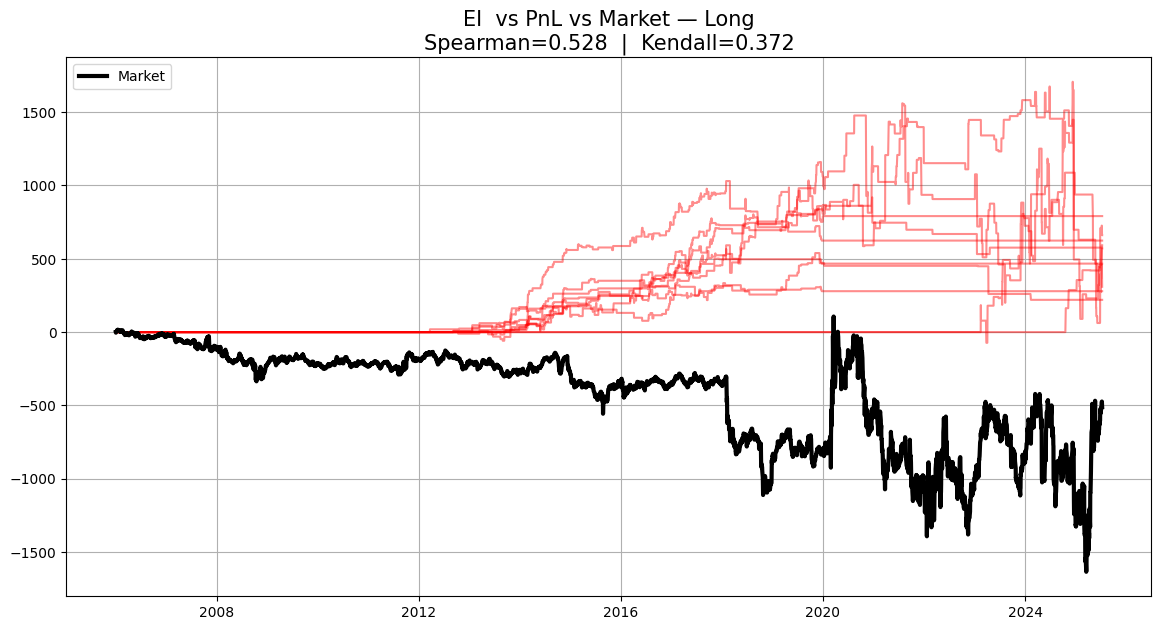

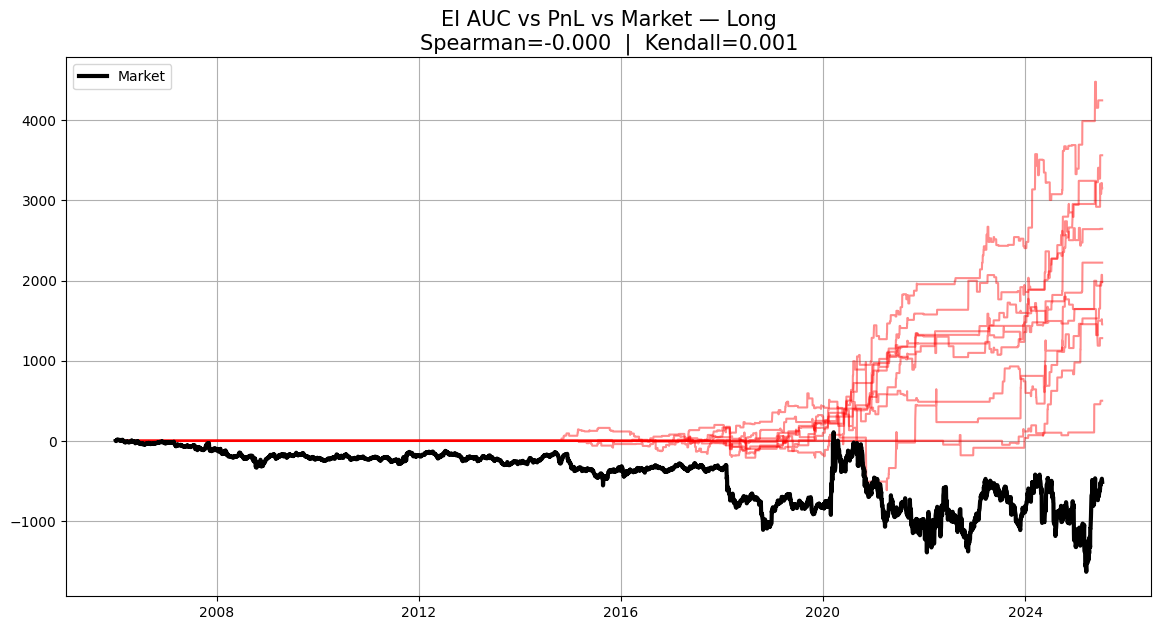

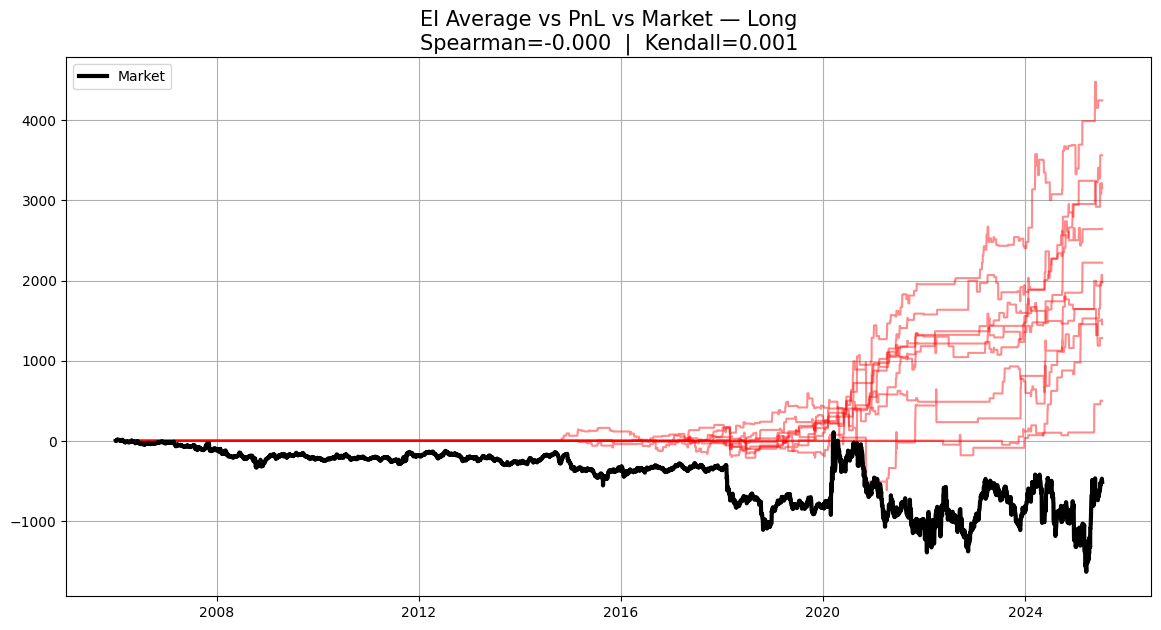

In [123]:
# 图 1 —— EI vs PnL vs Market
plot_ei_metric_vs_pnl_market(
    EI.iloc[-1],                  # 每个 trader 最终 EI
    final_pnl_long,
    pnl_timeseries['long_pnl'],
    market_long,
    title="EI  vs PnL vs Market — Long"
)

# 图 2 —— EI-AUC vs PnL vs Market
plot_ei_metric_vs_pnl_market(
    EI_AUC,
    final_pnl_long,
    pnl_timeseries['long_pnl'],
    market_long,
    title="EI AUC vs PnL vs Market — Long"
)

# 图 3 —— EI-average vs PnL vs Market
plot_ei_metric_vs_pnl_market(
    EI_ave,
    final_pnl_long,
    pnl_timeseries['long_pnl'],
    market_long,
    title="EI Average vs PnL vs Market — Long"
)


##Spearman=0.528 EI 越高的策略，红色线越陡（PnL 更好）Kendall=0.372 → EI 与 PnL 排名有中等一致性

In [126]:
import pandas as pd
import numpy as np

# =======================
# 1. 计算所有 Long 的 EI 时间序列
# =======================
weights = apply_weight_scheme('categories_average') # 或你想用的任何 weight scheme
EI_long_trader = compute_EI_trader(long1M_traders, alpha=0.05, weights=weights).T

print("EI Time Series (Long) shape:", EI_long_trader.shape)
# index = date, columns = each trader


# =======================
# 2. 计算 3 个指标
# =======================

# EI_final = 最后一天
EI_final_long = EI_long_trader.iloc[-1, :]

# EI_AUC = 所有天数求和
EI_auc_long = EI_long_trader.sum(axis=0)

# EI_average = 平均值
EI_avg_long = EI_long_trader.mean(axis=0)


# =======================
# 3. 合成一个 DataFrame
# =======================
EI_rank_long = pd.DataFrame({
    "EI_final": EI_final_long,
    "EI_AUC": EI_auc_long,
    "EI_Avg": EI_avg_long
})

# 排名（越大越好）
EI_rank_long["Rank_final"] = EI_rank_long["EI_final"].rank(ascending=False).astype(int)
EI_rank_long["Rank_AUC"]   = EI_rank_long["EI_AUC"].rank(ascending=False).astype(int)
EI_rank_long["Rank_Avg"]   = EI_rank_long["EI_Avg"].rank(ascending=False).astype(int)

print("Ranking table built.")


# =======================
# 4. 输出前 10 名 和 后 10 名（每个指标）
# =======================

def show_top_bottom(df, col, name):
    print(f"\n============== {name}（Top 10）==============")
    print(df.sort_values(col, ascending=False).head(10))

    print(f"\n============== {name}（Bottom 10）==============")
    print(df.sort_values(col, ascending=False).tail(10))

# 输出 3 个指标的前/后 10        
show_top_bottom(EI_rank_long, "EI_final", "EI_final")
show_top_bottom(EI_rank_long, "EI_AUC", "EI_AUC")
show_top_bottom(EI_rank_long, "EI_Avg", "EI_Avg")


已应用权重方案: categories_average
类别权重:
  Returns: 0.250
  Drawdowns: 0.250
  Length: 0.250
  Volatility: 0.250
指标总数: 15, 权重总和: 1.000000
EI Time Series (Long) shape: (235, 141)
Ranking table built.

============== EI_final（Top 10）==============
          EI_final      EI_AUC    EI_Avg  Rank_final  Rank_AUC  Rank_Avg
247_long  0.849969  129.065767  0.549216           1        17        17
26_long   0.840912  128.344946  0.546149           2        18        18
242_long  0.822900  122.232583  0.520139           3        63        63
98_long   0.814309  121.920196  0.518809           4        65        65
109_long  0.812762  120.969456  0.514764           5        75        75
135_long  0.809143  123.071943  0.523710           6        60        60
229_long  0.806878  126.284670  0.537382           7        30        30
209_long  0.804793  125.011748  0.531965           8        46        46
177_long  0.802236  127.811244  0.543878           9        19        19
202_long  0.799772  114.133398 

/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/976733987.py:66: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-measures))


##Short

In [152]:
# get re-arrange dict (short)
time_hor = short1M['2_short'].index

short1M_traders = {}
for t in time_hor:
    records = {}
    for trader, df1 in short1M.items():
        records[trader] = df1.loc[t]
    short1M_traders[t] = pd.DataFrame.from_dict(records, orient='index')


In [157]:
EI_ave = EI.mean(axis = 0)
EI_short = compute_EI_trader(short1M_traders, alpha=0.05, weights=weight_vector).T
EI_AUC_short = EI.sum(axis=0)
EI_ave_short = EI.mean(axis = 0)
print(EI_short.head())
print(EI_AUC_short.head())
print(EI_ave_short.head())

             2_short   3_short   9_short  10_short  11_short  15_short  \
2006-01-31  0.474186  0.457651  0.323964  0.514464  0.524960  0.354706   
2006-02-28  0.474170  0.457485  0.323943  0.513990  0.524563  0.354637   
2006-03-31  0.474152  0.457281  0.323919  0.513437  0.524081  0.354557   
2006-04-30  0.474181  0.457593  0.323957  0.514297  0.524821  0.354681   
2006-05-31  0.474136  0.457101  0.323898  0.512973  0.523658  0.354490   

            19_short  20_short  22_short  25_short  ...  245_short  246_short  \
2006-01-31  0.346877  0.504077  0.502591  0.453827  ...   0.499921   0.324061   
2006-02-28  0.346739  0.504068  0.502556  0.453775  ...   0.499804   0.324037   
2006-03-31  0.346579  0.504058  0.502515  0.453715  ...   0.499671   0.324010   
2006-04-30  0.346828  0.504074  0.502578  0.453809  ...   0.499879   0.324053   
2006-05-31  0.346445  0.504049  0.502481  0.453665  ...   0.499561   0.323987   

            249_short  250_short  251_short  262_short  263_short  2

/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/976733987.py:66: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-measures))


In [158]:
EI_short.describe()

,2_short,3_short,9_short,10_short,11_short,15_short,19_short,20_short,22_short,25_short,...,245_short,246_short,249_short,250_short,251_short,262_short,263_short,264_short,265_short,naive_ave_pnl
count,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,...,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,0.524424,0.496891,0.391070,0.557298,0.565528,0.442393,0.431271,0.570699,0.558042,0.538300,...,0.547054,0.430123,0.490881,0.536327,0.528832,0.537239,0.527390,0.513999,0.560591,0.542513
std,0.072756,0.067514,0.096735,0.066658,0.071700,0.100923,0.093181,0.065995,0.074155,0.088171,...,0.066557,0.099553,0.070114,0.068378,0.064264,0.063109,0.063358,0.068465,0.064500,0.099340
min,0.373752,0.404590,0.322596,0.389269,0.442337,0.352614,0.342424,0.445934,0.416388,0.407974,...,0.425860,0.323332,0.421955,0.389336,0.388267,0.424971,0.407672,0.447038,0.424206,0.359692
25%,0.473826,0.450560,0.323421,0.505879,0.512606,0.353292,0.344170,0.503899,0.501853,0.452816,...,0.497886,0.323596,0.450272,0.506926,0.500947,0.499585,0.501117,0.480287,0.502485,0.455731
50%,0.530885,0.454905,0.323601,0.554119,0.555455,0.392488,0.422167,0.587212,0.578826,0.557767,...,0.532074,0.437838,0.452067,0.507392,0.501407,0.499974,0.501311,0.480770,0.570815,0.527323
75%,0.579251,0.541078,0.444113,0.606500,0.637759,0.566105,0.533298,0.617145,0.620459,0.595481,...,0.598622,0.525752,0.537164,0.560574,0.560592,0.583344,0.559660,0.481682,0.617312,0.616388
max,0.647370,0.628270,0.601496,0.691364,0.685910,0.610969,0.616538,0.691292,0.668401,0.685805,...,0.681665,0.620140,0.688598,0.694101,0.658667,0.684751,0.655888,0.721734,0.661881,0.730492


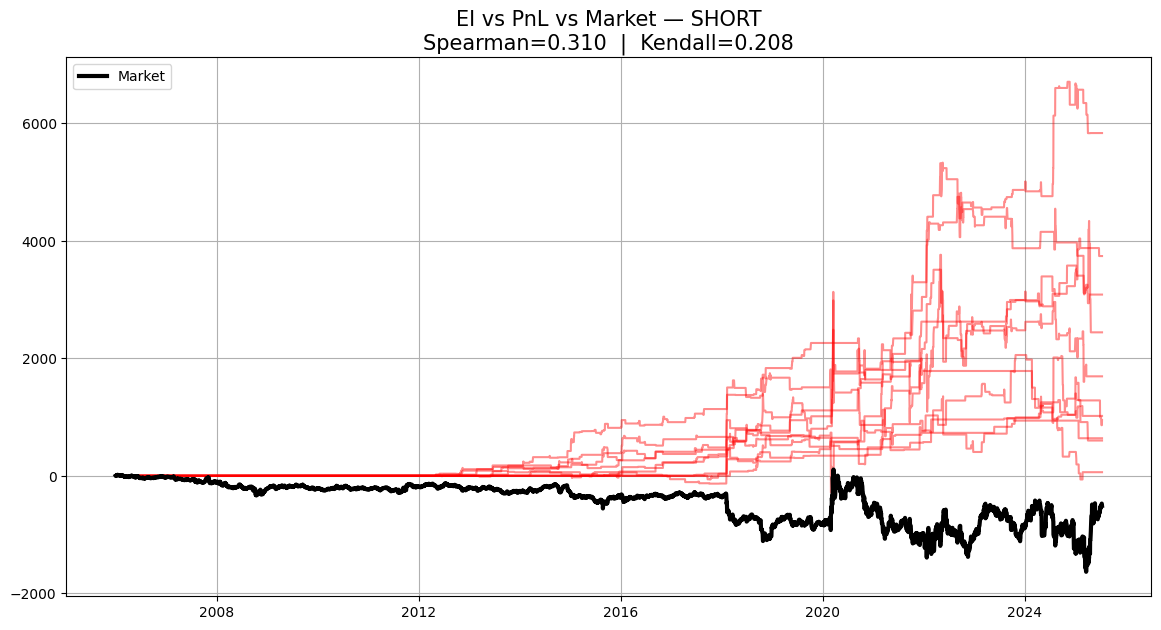

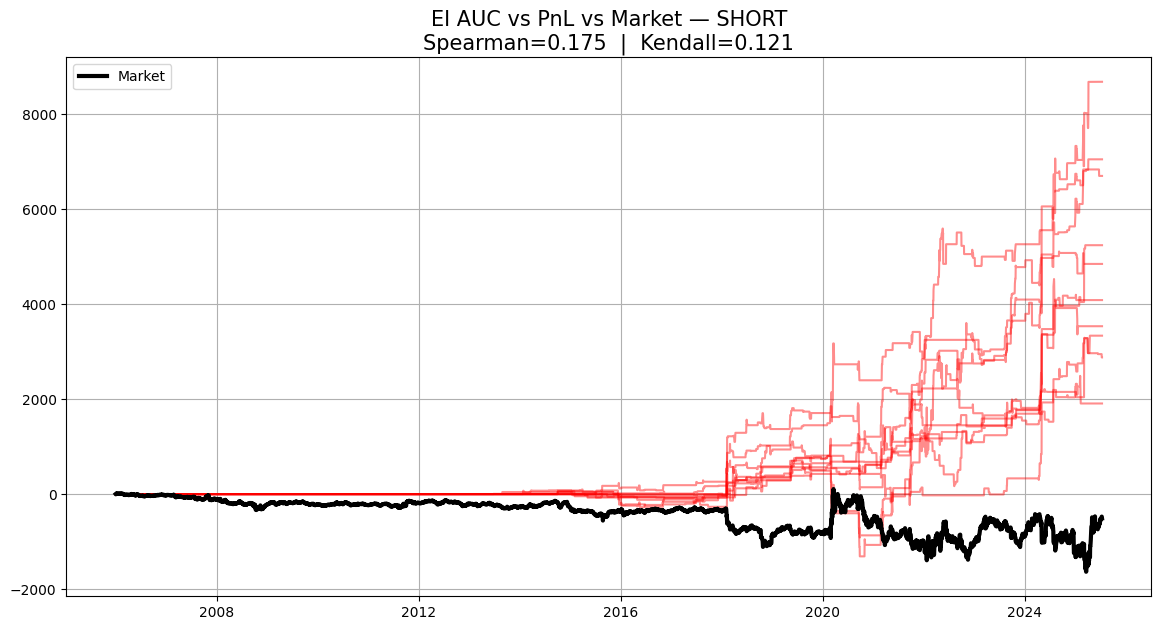

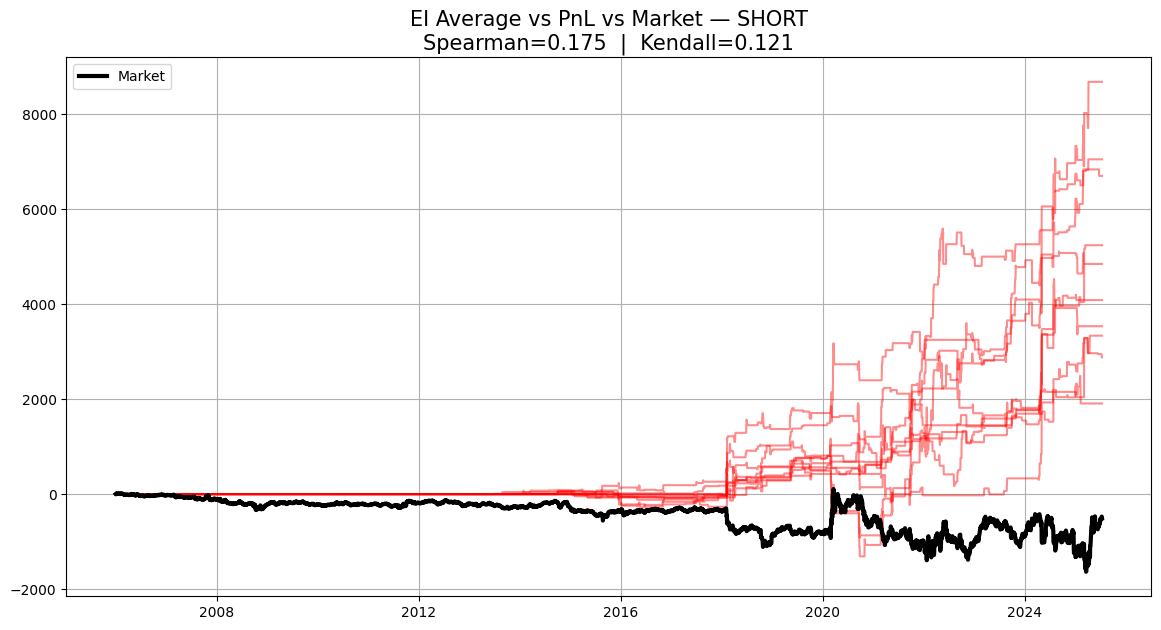

In [159]:
# 图 1 —— EI vs PnL vs Market (Short)
plot_ei_metric_vs_pnl_market(
    EI_short.iloc[-1],                  # 每个 short trader 最终 EI
    final_pnl_short,
    pnl_timeseries['short_pnl'],
    market_short,
    title="EI vs PnL vs Market — SHORT"
)

# 图 2 —— EI-AUC vs PnL vs Market (Short)
plot_ei_metric_vs_pnl_market(
    EI_AUC_short,
    final_pnl_short,
    pnl_timeseries['short_pnl'],
    market_short,
    title="EI AUC vs PnL vs Market — SHORT"
)

# 图 3 —— EI-average vs PnL vs Market (Short)
plot_ei_metric_vs_pnl_market(
    EI_ave_short,
    final_pnl_short,
    pnl_timeseries['short_pnl'],
    market_short,
    title="EI Average vs PnL vs Market — SHORT"
)


In [160]:
import pandas as pd
import numpy as np

# =======================
# 1. 计算所有 Short 的 EI 时间序列
# =======================
weights = apply_weight_scheme('categories_average')  # 用同样的权重方案

EI_short_trader = compute_EI_trader(short1M_traders, alpha=0.05, weights=weights).T

print("EI Time Series (Short) shape:", EI_short_trader.shape)
# index = date, columns = each short trader


# =======================
# 2. 计算 3 个指标（short）
# =======================

# EI_final = 最后一天
EI_final_short = EI_short_trader.iloc[-1, :]

# EI_AUC = 所有天数求和
EI_auc_short = EI_short_trader.sum(axis=0)

# EI_average = 平均值
EI_avg_short = EI_short_trader.mean(axis=0)


# =======================
# 3. 合成一个 DataFrame（short）
# =======================
EI_rank_short = pd.DataFrame({
    "EI_final": EI_final_short,
    "EI_AUC": EI_auc_short,
    "EI_Avg": EI_avg_short
})

# 排名（越大越好）
EI_rank_short["Rank_final"] = EI_rank_short["EI_final"].rank(ascending=False).astype(int)
EI_rank_short["Rank_AUC"]   = EI_rank_short["EI_AUC"].rank(ascending=False).astype(int)
EI_rank_short["Rank_Avg"]   = EI_rank_short["EI_Avg"].rank(ascending=False).astype(int)

print("Short ranking table built.")


# =======================
# 4. 输出前 10 名 和 后 10 名（short）
# =======================

def show_top_bottom(df, col, name):
    print(f"\n============== {name}（Top 10）==============")
    print(df.sort_values(col, ascending=False).head(10))

    print(f"\n============== {name}（Bottom 10）==============")
    print(df.sort_values(col, ascending=False).tail(10))

# 输出 3 个指标的前/后 10 (short)
show_top_bottom(EI_rank_short, "EI_final", "EI_final")
show_top_bottom(EI_rank_short, "EI_AUC", "EI_AUC")
show_top_bottom(EI_rank_short, "EI_Avg", "EI_Avg")


已应用权重方案: categories_average
类别权重:
  Returns: 0.250
  Drawdowns: 0.250
  Length: 0.250
  Volatility: 0.250
指标总数: 15, 权重总和: 1.000000
EI Time Series (Short) shape: (235, 127)
Short ranking table built.

============== EI_final（Top 10）==============
               EI_final      EI_AUC    EI_Avg  Rank_final  Rank_AUC  Rank_Avg
naive_ave_pnl  0.768496  117.924637  0.501807           1       103       103
29_short       0.747842  121.815967  0.518366           2        92        92
200_short      0.728125  134.173519  0.570951           3         7         7
91_short       0.713702  126.169144  0.536890           4        58        58
82_short       0.711959  125.200291  0.532767           5        68        68
141_short      0.709451  127.489103  0.542507           6        45        45
41_short       0.708160  124.331118  0.529069           7        74        74
220_short      0.707226  134.523615  0.572441           8         6         6
243_short      0.706877  132.643415  0.564440       

/var/folders/61/x7sq28wj59q80j5h8qfsxbl80000gn/T/ipykernel_70062/976733987.py:66: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-measures))


## PCA分析EI，EI AUC，EI Ave中重要的成分有几个



===== PCA for LONG =====
Explained Variance Ratio: [0.67305877 0.32694123 0.        ]
Principal Components:
  PC1: [0.13589702 0.70054693 0.70054693]
  PC2: [ 0.99072297 -0.09609371 -0.09609371]
  PC3: [-4.06096198e-17  7.07106781e-01 -7.07106781e-01]


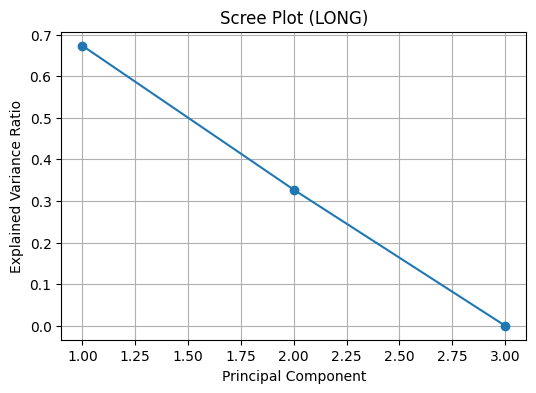

In [161]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def run_pca_and_plot(df, title):
    X = df[['EI_final','EI_AUC','EI_Avg']].values
    X = StandardScaler().fit_transform(X)

    pca = PCA()
    pca.fit(X)

    explained = pca.explained_variance_ratio_
    pcs = pca.components_

    print(f"\n===== PCA for {title} =====")
    print("Explained Variance Ratio:", explained)
    print("Principal Components:")
    for i, comp in enumerate(pcs):
        print(f"  PC{i+1}: {comp}")

    # Scree plot
    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(explained)+1), explained, marker='o')
    plt.title(f'Scree Plot ({title})')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.grid(True)
    plt.show()

# 运行 PCA
run_pca_and_plot(EI_rank_long, "LONG")



===== PCA for SHORT =====
Explained Variance Ratio: [0.68620814 0.31379186 0.        ]
Principal Components:
  PC1: [0.22906794 0.68830512 0.68830512]
  PC2: [ 0.97341044 -0.1619755  -0.1619755 ]
  PC3: [-6.36476857e-17  7.07106781e-01 -7.07106781e-01]


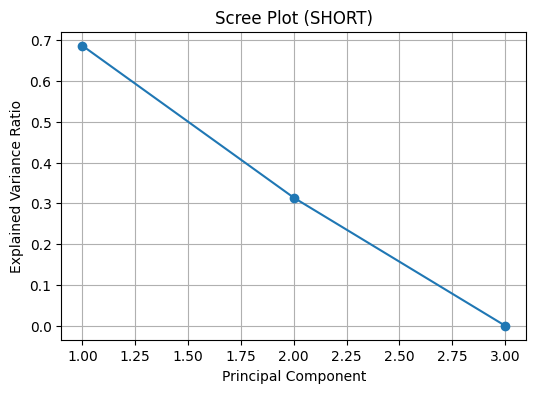

In [164]:
run_pca_and_plot(EI_rank_short, "SHORT")


## 
PC1	长期稳定性因子（由 EI_AUC 与 EI_Avg 主导）	67%	69%（long&short）

PC2	终局表现因子（由 EI_final 主导）	33%	31%（long&short）

## Clustering（多种办法）去看EI是否能代表PnL



In [172]:
X_long = np.column_stack([
    EI_final_long,
    EI_auc_long,
    EI_avg_long
])

y_long = final_pnl_long.values


In [1]:
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score



def evaluate_clustering(X, pnl, labels, name):
    df = pd.DataFrame({"cluster": labels, "pnl": pnl})
    pnl_by_cluster = df.groupby("cluster")["pnl"].mean()

    sil = silhouette_score(X, labels)

    print(f"\n===== {name} =====")
    print("Cluster PnL means:")
    print(pnl_by_cluster)
    print(f"Silhouette Score: {sil:.4f}")
    return pnl_by_cluster, sil

def run_all_clusterings(X, pnl):
    results = {}

    # 1) KMeans
    km = KMeans(n_clusters=3, random_state=42)
    km_labels = km.fit_predict(X)
    results["kmeans"] = evaluate_clustering(X, pnl, km_labels, "KMeans")

    # 2) Spectral Clustering
    sc = SpectralClustering(n_clusters=3, affinity='rbf', random_state=42)
    sc_labels = sc.fit_predict(X)
    results["spectral"] = evaluate_clustering(X, pnl, sc_labels, "Spectral")

    # 3) Agglomerative
    ag = AgglomerativeClustering(n_clusters=3)
    ag_labels = ag.fit_predict(X)
    results["agg"] = evaluate_clustering(X, pnl, ag_labels, "Agglomerative")

    # 4) Gaussian Mixture (GMM)
    gm = GaussianMixture(n_components=3, random_state=42)
    gm_labels = gm.fit_predict(X)
    results["gmm"] = evaluate_clustering(X, pnl, gm_labels, "GMM")

    return results


In [181]:
### 1. 找到共同的策略集合
common = EI_final_long.index.intersection(final_pnl_long.index)

EI_final_long = EI_final_long.loc[common]
EI_auc_long   = EI_auc_long.loc[common]
EI_avg_long   = EI_avg_long.loc[common]
final_pnl_long = final_pnl_long.loc[common]

### 2. 重新构造 X 和 y
X_long = np.column_stack([
    EI_final_long.values,
    EI_auc_long.values,
    EI_avg_long.values
])

y_long = final_pnl_long.values

print("X_long shape:", X_long.shape)
print("y_long shape:", y_long.shape)

### 3. 重新运行 clustering
results_long = run_all_clusterings(X_long, y_long)


X_long shape: (140, 3)
y_long shape: (140,)

===== KMeans =====
Cluster PnL means:
cluster
0    2234.530612
1    1955.625000
2    2197.813333
Name: pnl, dtype: float64
Silhouette Score: 0.5956

===== Spectral =====
Cluster PnL means:
cluster
0    2164.977273
1    2434.000000
2    2495.500000
Name: pnl, dtype: float64
Silhouette Score: 0.6085

===== Agglomerative =====
Cluster PnL means:
cluster
0    2197.813333
1    1955.625000
2    2234.530612
Name: pnl, dtype: float64
Silhouette Score: 0.5956

===== GMM =====
Cluster PnL means:
cluster
0    2706.534884
1    1679.833333
2    1084.666667
Name: pnl, dtype: float64
Silhouette Score: 0.1123


In [182]:
## 1. 找到共同的策略集合（short）
common_short = EI_final_short.index.intersection(final_pnl_short.index)

EI_final_short = EI_final_short.loc[common_short]
EI_auc_short   = EI_auc_short.loc[common_short]
EI_avg_short   = EI_avg_short.loc[common_short]
final_pnl_short = final_pnl_short.loc[common_short]

### 2. 重新构造 X_short 和 y_short
X_short = np.column_stack([
    EI_final_short.values,
    EI_auc_short.values,
    EI_avg_short.values
])

y_short = final_pnl_short.values

print("X_short shape:", X_short.shape)
print("y_short shape:", y_short.shape)

### 3. 重新运行 clustering（short）
print("==== SHORT Clustering ====")
results_short = run_all_clusterings(X_short, y_short)


X_short shape: (126, 3)
y_short shape: (126,)
==== SHORT Clustering ====

===== KMeans =====
Cluster PnL means:
cluster
0    4512.704225
1    4587.928571
2    4321.853659
Name: pnl, dtype: float64
Silhouette Score: 0.5548

===== Spectral =====
Cluster PnL means:
cluster
0    4442.839286
1    4815.181818
2    3754.666667
Name: pnl, dtype: float64
Silhouette Score: 0.6216

===== Agglomerative =====
Cluster PnL means:
cluster
0    4410.500000
1    4587.928571
2    4549.807692
Name: pnl, dtype: float64
Silhouette Score: 0.4737

===== GMM =====
Cluster PnL means:
cluster
0    2333.838710
1    4587.928571
2    5249.987654
Name: pnl, dtype: float64
Silhouette Score: 0.2532


## 用 EI filter，选出top 10 curve，和naive average 还可以选middle 10， last 10 对比）



In [197]:
# EI 选择器（你也可以换成 EI_long_minmax）
EI_used = EI_long_zscore.copy()

# 排序
EI_sorted = EI_used.sort_values(ascending=False)

# Top / Middle / Bottom 组
top10 = EI_sorted.index[:10]
mid10 = EI_sorted.index[len(EI_sorted)//2 - 5 : len(EI_sorted)//2 + 5]
bottom10 = EI_sorted.index[-10:]

print("Top 10:", list(top10))
print("Middle 10:", list(mid10))
print("Bottom 10:", list(bottom10))


Top 10: ['116_long', '231_long', '190_long', '0_long', '252_long', '142_long', '209_long', '219_long', '14_long', '206_long']
Middle 10: ['38_long', '16_long', '228_long', '54_long', '107_long', '150_long', '195_long', '254_long', '259_long', '122_long']
Bottom 10: ['118_long', '21_long', '98_long', '172_long', '112_long', '115_long', '18_long', '149_long', '40_long', '69_long']


In [72]:
naive_long = pnl_timeseries['long_pnl'].mean(axis=1)


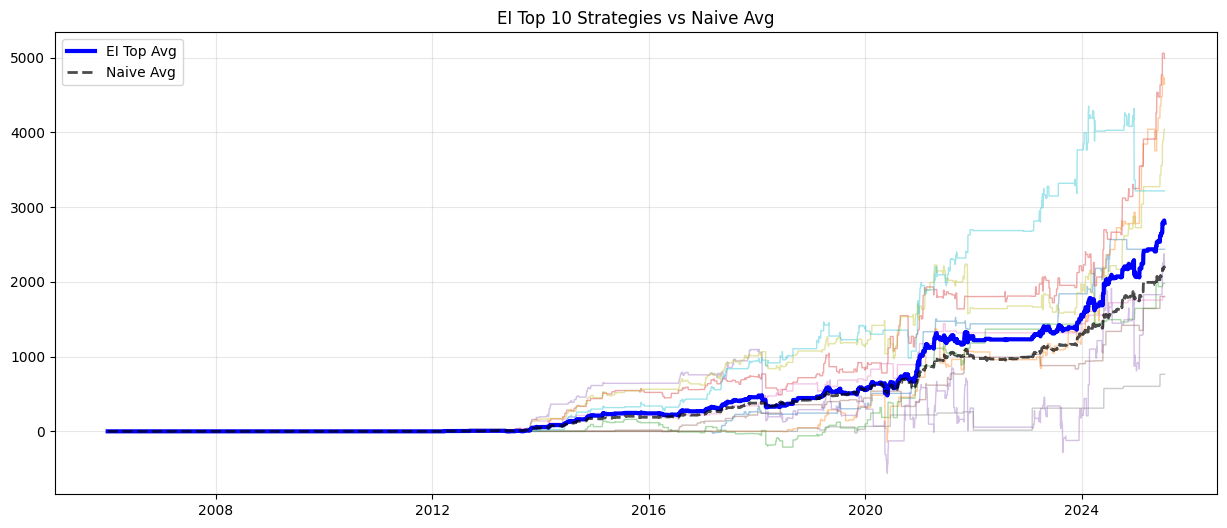

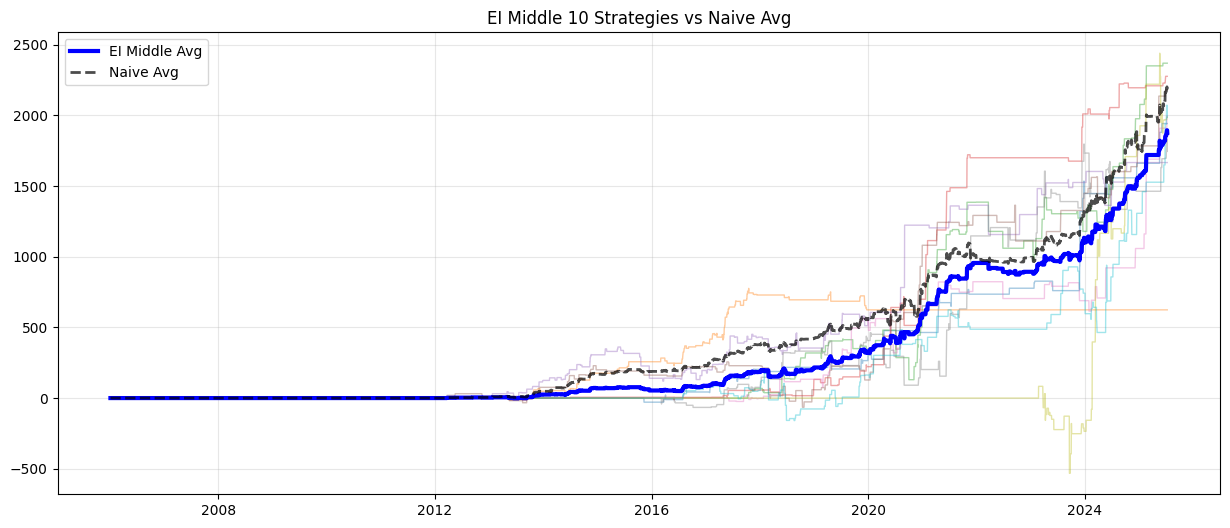

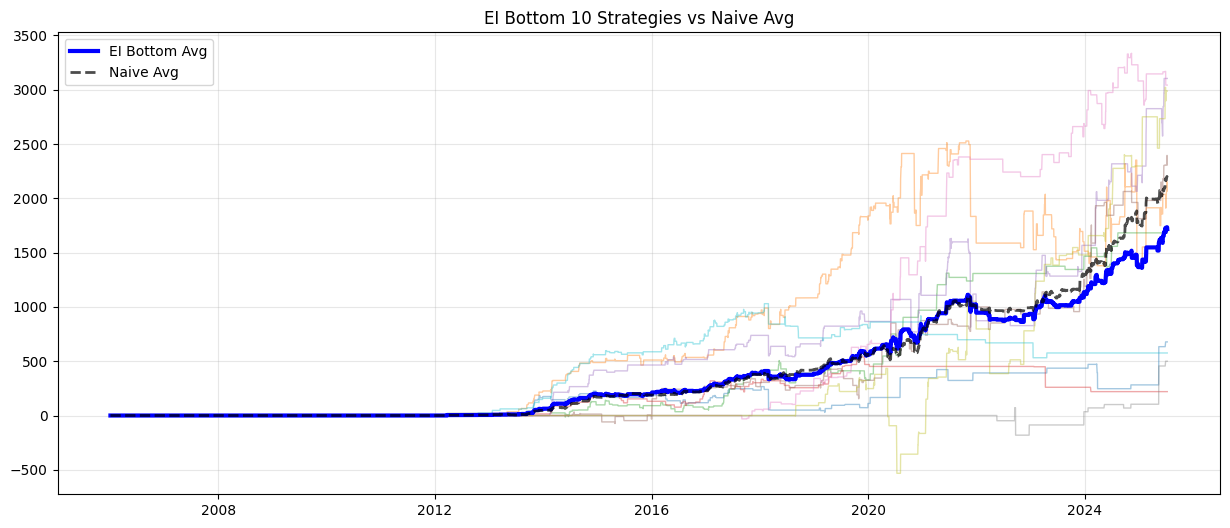

In [73]:
import matplotlib.pyplot as plt

def plot_group(group, title):
    plt.figure(figsize=(15,6))

    # group 策略曲线
    for s in group:
        plt.plot(pnl_timeseries['long_pnl'][s], alpha=0.4, lw=1)

    # group average（粗线）
    group_avg = pnl_timeseries['long_pnl'][group].mean(axis=1)
    plt.plot(group_avg, c='blue', lw=3, label=f"{title} Avg")

    # naive average baseline
    plt.plot(naive_long, c='black', lw=2, ls='--', alpha=0.7, label="Naive Avg")

    plt.title(f"{title} 10 Strategies vs Naive Avg")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# === 三张图 ===
plot_group(top10,   "EI Top")
plot_group(mid10,   "EI Middle")
plot_group(bottom10,"EI Bottom")


In [198]:
# EI 选择器 —— short 版本
EI_used_short = EI_short_zscore.copy()   # 换成 short EI z-score

# 排序（从大到小 = EI 好 → 前面）
EI_sorted_short = EI_used_short.sort_values(ascending=False)

# Top 10
top10_short = EI_sorted_short.index[:10]

# Middle 10（取中间位置前后 5 个）
mid_start = len(EI_sorted_short)//2 - 5
mid10_short = EI_sorted_short.index[mid_start : mid_start + 10]

# Bottom 10
bottom10_short = EI_sorted_short.index[-10:]

print("Top 10 SHORT:", list(top10_short))
print("Middle 10 SHORT:", list(mid10_short))
print("Bottom 10 SHORT:", list(bottom10_short))


Top 10 SHORT: ['3_short', '262_short', '131_short', '77_short', '178_short', '241_short', '147_short', '32_short', '94_short', '108_short']
Middle 10 SHORT: ['81_short', '153_short', '160_short', '189_short', '198_short', '187_short', '20_short', '65_short', '132_short', '49_short']
Bottom 10 SHORT: ['133_short', '165_short', '10_short', '188_short', '63_short', '2_short', '181_short', '37_short', '223_short', '264_short']


In [199]:
naive_short = pnl_timeseries['short_pnl'].mean(axis=1)

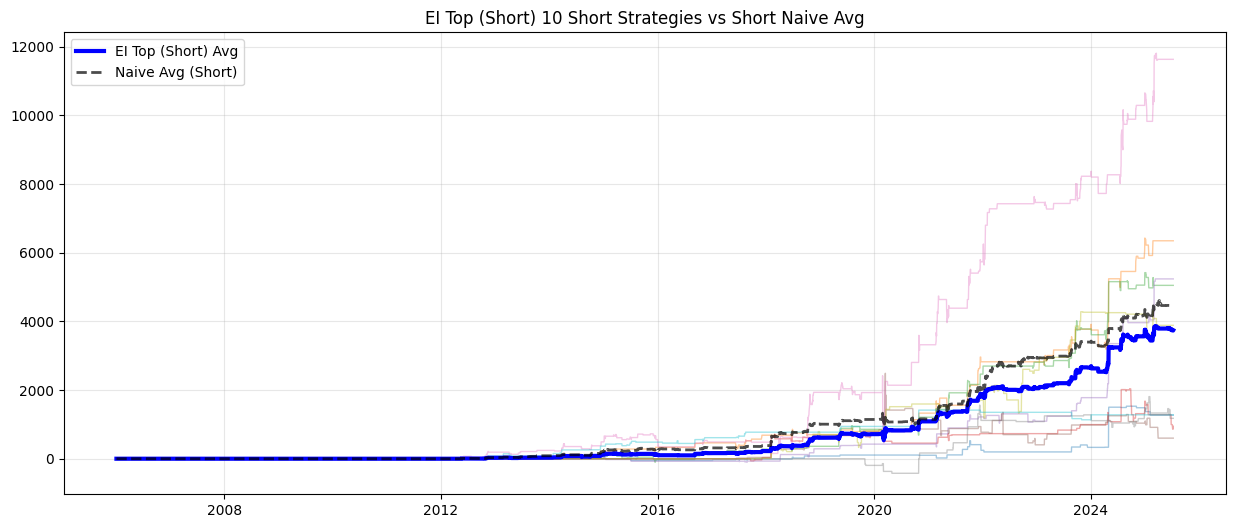

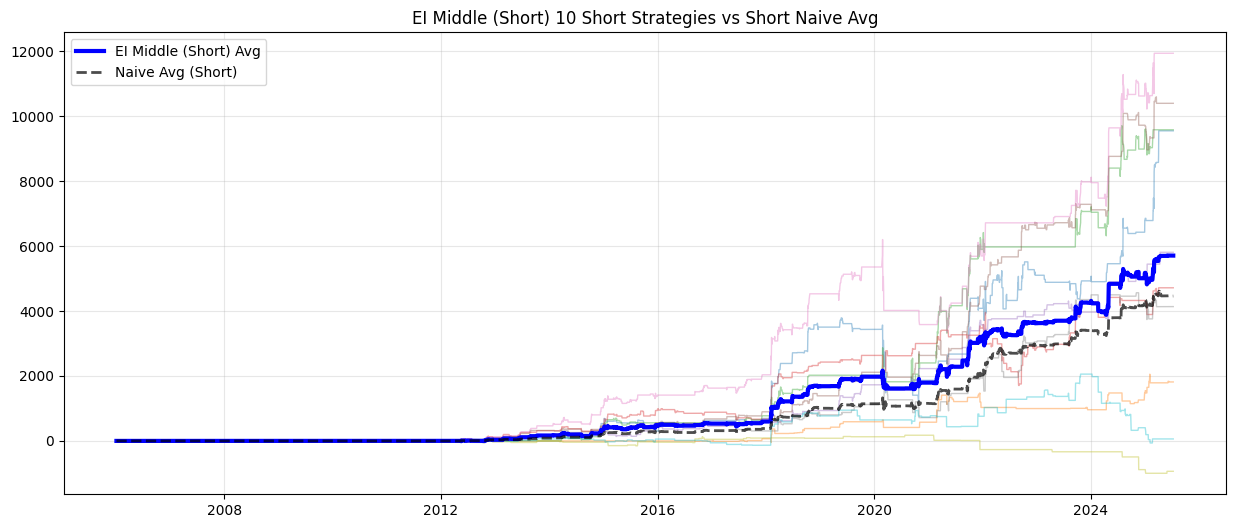

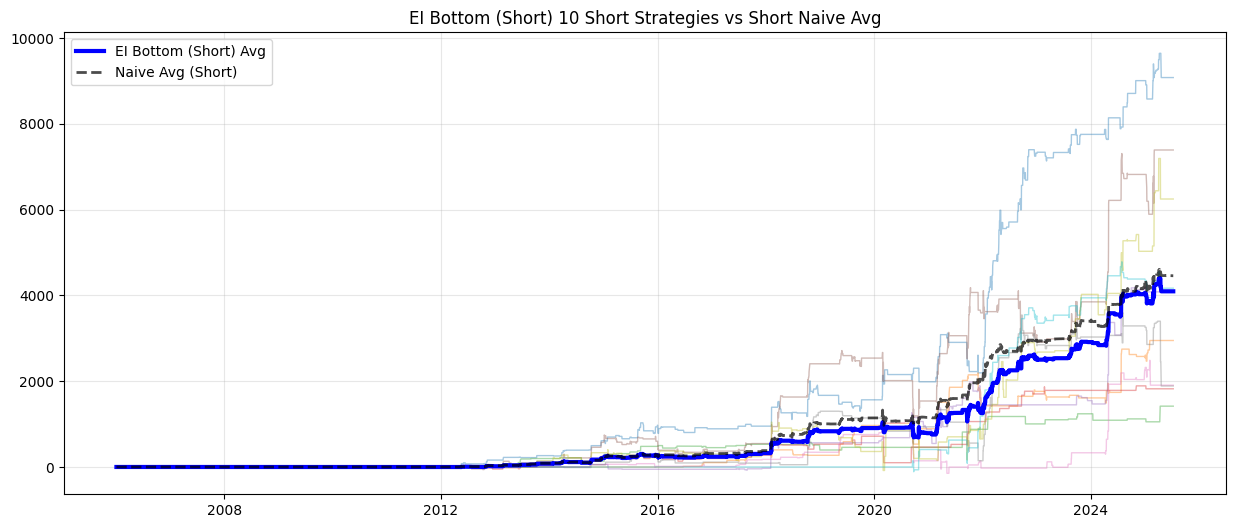

In [201]:
import matplotlib.pyplot as plt

def plot_group_short(group, title):
    plt.figure(figsize=(15,6))

    # group 策略曲线（short）
    for s in group:
        plt.plot(pnl_timeseries['short_pnl'][s], alpha=0.4, lw=1)

    # group average（粗线）
    group_avg = pnl_timeseries['short_pnl'][group].mean(axis=1)
    plt.plot(group_avg, c='blue', lw=3, label=f"{title} Avg")

    # naive average baseline — short
    naive_short = pnl_timeseries['short_pnl'].mean(axis=1)
    plt.plot(naive_short, c='black', lw=2, ls='--', alpha=0.7, label="Naive Avg (Short)")

    plt.title(f"{title} 10 Short Strategies vs Short Naive Avg")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    # ==== 三张图（SHORT）====
plot_group_short(top10_short,   "EI Top (Short)")
plot_group_short(mid10_short,   "EI Middle (Short)")
plot_group_short(bottom10_short,"EI Bottom (Short)")

